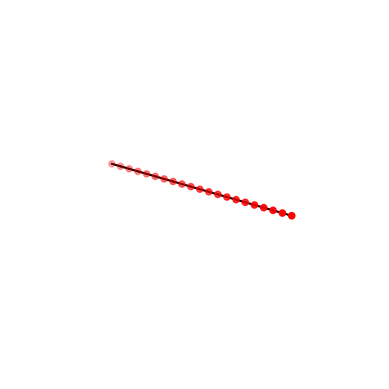

In [1]:
import numpy as np

import dismech

b = 0.02
h = 0.001

geom = dismech.GeomParams(rod_r0=0.001,
                          shell_h=0,
                          axs=b*h,
                          ixs1=b*h**3/12,
                          ixs2=h*b**3/12,
                          jxs=b*h**3/6)

material = dismech.Material(density=1200,
                            youngs_rod=5e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dynamic_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=True,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2,
                                  use_predictor_corrector_for_ground_contact=True
                                  )

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('floorContact', ground_z=-1e-2, stiffness=50, delta=1e-3, h=1e-3)

# geo = dismech.Geometry.from_txt(
#     '../tests/resources/rod_contact/input_straight_inclined_smaller_n21.txt')
geo = dismech.Geometry.from_txt(
    '../tests/resources/rod_cantilever/horizontal_rod_n21.txt')

robot = dismech.SoftRobot(geom, material, geo, dynamic_sim, env)

## Predictor-Corrector Ground Contact

Drops an inclined rod onto a fixed ground using the predictor-corrector scheme (`use_predictor_corrector_for_ground_contact=True`). The `floorContact` env force supplies the ground geometry (`ground_z`, `ground_h`, `ground_delta`); the penalty force itself is skipped automatically while the predictor-corrector is active.

### Time stepping

In [2]:
stepper = dismech.ImplicitEulerTimeStepper(robot)
robots, t_arr, f_norms, Fs = stepper.simulate()

qs = np.stack([r.state.q for r in robots])
t_arr = np.array(t_arr[:len(qs)])

iter: 1, error: 0.005
iter: 2, error: 0.000
current_time:  0.01
iter: 1, error: 0.010
iter: 2, error: 0.000
current_time:  0.02
iter: 1, error: 0.016
iter: 2, error: 0.000
current_time:  0.03
iter: 1, error: 0.021
iter: 2, error: 0.000
iter: 1, error: 0.000
current_time:  0.04
iter: 1, error: 0.000
current_time:  0.05
iter: 1, error: 0.000
current_time:  0.060000000000000005
iter: 1, error: 0.000
current_time:  0.07
iter: 1, error: 0.000
current_time:  0.08
iter: 1, error: 0.000
current_time:  0.09
iter: 1, error: 0.000
current_time:  0.09999999999999999
iter: 1, error: 0.000
current_time:  0.10999999999999999
iter: 1, error: 0.000
current_time:  0.11999999999999998
iter: 1, error: 0.000
current_time:  0.12999999999999998
iter: 1, error: 0.000
current_time:  0.13999999999999999
iter: 1, error: 0.000
current_time:  0.15
iter: 1, error: 0.000
current_time:  0.16
iter: 1, error: 0.000
current_time:  0.17
iter: 1, error: 0.000
current_time:  0.18000000000000002
iter: 1, error: 0.000
curren

### Visualization

In [3]:
options = dismech.AnimationOptions(
    title='Predictor-Corrector Ground Contact (rod, N=21)',
    # z_lim=(robot.env.ground_z + robot.env.ground_h - 1e-3,
    #        qs[:, 2::3].max() + 1e-3),
)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()